<a href="https://colab.research.google.com/github/Kishoby/Churn_Prediction_ML/blob/Feature_Importance/Churn_Feature_Importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import shutil

from sklearn.inspection import permutation_importance

In [2]:
split_path = (
    "/content/drive/MyDrive/Project_Churn Prediction/"
    "03_Train_Test_Split"
)

model_path = (
    "/content/drive/MyDrive/Project_Churn Prediction/"
    "04_Model_Training"
)

evaluation_path = (
    "/content/drive/MyDrive/Project_Churn Prediction/"
    "05_Model_Evaluation"
)

importance_path = (
    "/content/drive/MyDrive/Project_Churn Prediction/"
    "06_Feature_Importance"
)

image_path = os.path.join(
    importance_path,
    "Images"
)

os.makedirs(importance_path, exist_ok=True)
os.makedirs(image_path, exist_ok=True)

print("Feature importance folder created successfully.")
print(importance_path)

Feature importance folder created successfully.
/content/drive/MyDrive/Project_Churn Prediction/06_Feature_Importance


In [3]:
X_test = pd.read_csv(
    f"{split_path}/X_test.csv"
)

y_test = pd.read_csv(
    f"{split_path}/y_test.csv"
).squeeze("columns")

print("Testing data loaded successfully.")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Testing data loaded successfully.
X_test shape: (1407, 58)
y_test shape: (1407,)


In [4]:
feature_names = pd.read_csv(
    f"{model_path}/Model_Feature_Names.csv"
)["Feature_Name"].tolist()

print("Number of saved features:", len(feature_names))

Number of saved features: 58


In [5]:
missing_features = [
    feature for feature in feature_names
    if feature not in X_test.columns
]

extra_features = [
    feature for feature in X_test.columns
    if feature not in feature_names
]

print("Missing features:", missing_features)
print("Extra features:", extra_features)

if missing_features or extra_features:
    raise ValueError(
        "X_test features do not match the training features."
    )

X_test = X_test[feature_names]

print("Feature order verified successfully.")

Missing features: []
Extra features: []
Feature order verified successfully.


In [6]:
model_files = {
    "Logistic Regression":
        "Logistic_Regression_Model.pkl",

    "Decision Tree":
        "Decision_Tree_Model.pkl",

    "Random Forest":
        "Random_Forest_Model.pkl",

    "Gradient Boosting":
        "Gradient_Boosting_Model.pkl"
}

In [7]:
models = {}

for model_name, filename in model_files.items():

    full_path = os.path.join(
        model_path,
        filename
    )

    if not os.path.exists(full_path):
        raise FileNotFoundError(
            f"Model file not found: {full_path}"
        )

    models[model_name] = joblib.load(
        full_path
    )

    print(f"{model_name} loaded successfully.")


Logistic Regression loaded successfully.
Decision Tree loaded successfully.
Random Forest loaded successfully.
Gradient Boosting loaded successfully.


In [8]:
def calculate_tree_importance(
    model,
    feature_names,
    model_name
):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    importance_df["Rank"] = (
        importance_df.index + 1
    )

    importance_df["Model"] = model_name

    return importance_df[
        [
            "Rank",
            "Feature",
            "Importance",
            "Model"
        ]
    ]

In [9]:
decision_tree_importance = (
    calculate_tree_importance(
        models["Decision Tree"],
        feature_names,
        "Decision Tree"
    )
)

display(
    decision_tree_importance.head(20)
)

,Rank,Feature,Importance,Model
0,1,ChargesPerContractMonth,0.642503,Decision Tree
1,2,tenure,0.096707,Decision Tree
2,3,AverageMonthlySpend,0.035855,Decision Tree
3,4,TotalCharges,0.030813,Decision Tree
4,5,PaymentMethod_Electronic check,0.021903,Decision Tree
5,6,MonthlyCharges_ServiceCount_Interaction,0.021538,Decision Tree
6,7,InternetService_Fiber optic,0.018128,Decision Tree
7,8,Tenure_MonthlyCharges_Interaction,0.013825,Decision Tree
8,9,Tenure_ServiceCount_Interaction,0.013512,Decision Tree
9,10,NoSecurityOrTechSupport,0.013495,Decision Tree


In [10]:
decision_tree_importance.to_csv(
    f"{importance_path}/"
    "Decision_Tree_Feature_Importance.csv",
    index=False
)

In [11]:
random_forest_importance = (
    calculate_tree_importance(
        models["Random Forest"],
        feature_names,
        "Random Forest"
    )
)

display(
    random_forest_importance.head(20)
)

,Rank,Feature,Importance,Model
0,1,ChargesPerContractMonth,0.119451,Random Forest
1,2,TotalCharges,0.062886,Random Forest
2,3,Tenure_MonthlyCharges_Interaction,0.062515,Random Forest
3,4,tenure,0.061426,Random Forest
4,5,AverageMonthlySpend,0.060027,Random Forest
5,6,ContractDurationMonths,0.057915,Random Forest
6,7,MonthlyCharges,0.056907,Random Forest
7,8,LongTermContract,0.044445,Random Forest
8,9,MonthlyCharges_ServiceCount_Interaction,0.040768,Random Forest
9,10,Tenure_ServiceCount_Interaction,0.038951,Random Forest


In [12]:
random_forest_importance.to_csv(
    f"{importance_path}/"
    "Random_Forest_Feature_Importance.csv",
    index=False
)

In [13]:
gradient_boosting_importance = (
    calculate_tree_importance(
        models["Gradient Boosting"],
        feature_names,
        "Gradient Boosting"
    )
)

display(
    gradient_boosting_importance.head(20)
)

,Rank,Feature,Importance,Model
0,1,ChargesPerContractMonth,0.554868,Gradient Boosting
1,2,tenure,0.128759,Gradient Boosting
2,3,NoSecurityOrTechSupport,0.044802,Gradient Boosting
3,4,AverageMonthlySpend,0.039586,Gradient Boosting
4,5,FiberOpticCustomer,0.036532,Gradient Boosting
5,6,Tenure_MonthlyCharges_Interaction,0.035245,Gradient Boosting
6,7,TotalCharges,0.031087,Gradient Boosting
7,8,PaymentMethod_Electronic check,0.026300,Gradient Boosting
8,9,MonthlyCharges,0.015366,Gradient Boosting
9,10,InternetService_Fiber optic,0.014653,Gradient Boosting


In [16]:
logistic_pipeline = models[
    "Logistic Regression"
]

logistic_model = logistic_pipeline.named_steps[
    "model"
]

logistic_coefficients = (
    logistic_model.coef_[0]
)

In [17]:
logistic_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_coefficients
})

In [18]:
logistic_importance[
    "Absolute_Importance"
] = logistic_importance[
    "Coefficient"
].abs()

In [19]:
logistic_importance[
    "Effect"
] = np.where(
    logistic_importance["Coefficient"] > 0,
    "Increases Churn Probability",
    "Decreases Churn Probability"
)

In [20]:
logistic_importance = (
    logistic_importance
    .sort_values(
        by="Absolute_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

logistic_importance["Rank"] = (
    logistic_importance.index + 1
)

In [21]:
logistic_importance = logistic_importance[
    [
        "Rank",
        "Feature",
        "Coefficient",
        "Absolute_Importance",
        "Effect"
    ]
]

display(logistic_importance.head(20))

,Rank,Feature,Coefficient,Absolute_Importance,Effect
0,1,MonthlyCharges,-0.957497,0.957497,Decreases Churn Probability
1,2,tenure,-0.641756,0.641756,Decreases Churn Probability
2,3,MonthlyCharges_ServiceCount_Interaction,0.527646,0.527646,Increases Churn Probability
3,4,Tenure_MonthlyCharges_Interaction,-0.485351,0.485351,Decreases Churn Probability
4,5,InternetService_Fiber optic,0.432984,0.432984,Increases Churn Probability
5,6,FiberOpticCustomer,0.432984,0.432984,Increases Churn Probability
6,7,ChargesPerContractMonth,-0.382581,0.382581,Decreases Churn Probability
7,8,Tenure_ServiceCount_Interaction,0.328572,0.328572,Increases Churn Probability
8,9,ContractDurationMonths,-0.310800,0.310800,Decreases Churn Probability
9,10,Contract_Two year,-0.282647,0.282647,Decreases Churn Probability


In [22]:
logistic_importance.to_csv(
    f"{importance_path}/"
    "Logistic_Regression_Coefficient_Importance.csv",
    index=False
)

In [23]:
best_model_summary = pd.read_csv(
    f"{evaluation_path}/Best_Model_Summary.csv"
)

display(best_model_summary)

,Selection_Criterion,Best_Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision
0,Highest ROC-AUC,Gradient Boosting,0.7982,0.6442,0.5374,0.586,0.8364,0.6483


In [24]:
best_model_name = (
    best_model_summary.loc[
        0,
        "Best_Model"
    ]
)

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [25]:
best_model = joblib.load(
    f"{evaluation_path}/Best_Model.pkl"
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [26]:
if hasattr(
    best_model,
    "feature_importances_"
):

    best_native_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance":
            best_model.feature_importances_
    })

elif hasattr(
    best_model,
    "named_steps"
):

    final_model = best_model.named_steps[
        "model"
    ]

    if hasattr(
        final_model,
        "coef_"
    ):

        best_native_importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance":
                np.abs(final_model.coef_[0])
        })

    else:
        best_native_importance = None

else:
    best_native_importance = None

In [27]:
if best_native_importance is not None:

    best_native_importance = (
        best_native_importance
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    best_native_importance["Rank"] = (
        best_native_importance.index + 1
    )

    best_native_importance[
        "Best_Model"
    ] = best_model_name

    best_native_importance = (
        best_native_importance[
            [
                "Rank",
                "Feature",
                "Importance",
                "Best_Model"
            ]
        ]
    )

    display(
        best_native_importance.head(20)
    )

    best_native_importance.to_csv(
        f"{importance_path}/"
        "Best_Model_Native_Feature_Importance.csv",
        index=False
    )

else:
    print(
        "Native feature importance is not "
        "available for this model."
    )

,Rank,Feature,Importance,Best_Model
0,1,ChargesPerContractMonth,0.554868,Gradient Boosting
1,2,tenure,0.128759,Gradient Boosting
2,3,NoSecurityOrTechSupport,0.044802,Gradient Boosting
3,4,AverageMonthlySpend,0.039586,Gradient Boosting
4,5,FiberOpticCustomer,0.036532,Gradient Boosting
5,6,Tenure_MonthlyCharges_Interaction,0.035245,Gradient Boosting
6,7,TotalCharges,0.031087,Gradient Boosting
7,8,PaymentMethod_Electronic check,0.026300,Gradient Boosting
8,9,MonthlyCharges,0.015366,Gradient Boosting
9,10,InternetService_Fiber optic,0.014653,Gradient Boosting


In [28]:
permutation_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance calculated successfully.")

Permutation importance calculated successfully.


In [29]:
permutation_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean":
        permutation_result.importances_mean,
    "Importance_Standard_Deviation":
        permutation_result.importances_std
})

In [30]:
permutation_df = (
    permutation_df
    .sort_values(
        by="Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_df["Rank"] = (
    permutation_df.index + 1
)

permutation_df["Best_Model"] = (
    best_model_name
)

In [31]:
permutation_df = permutation_df[
    [
        "Rank",
        "Feature",
        "Importance_Mean",
        "Importance_Standard_Deviation",
        "Best_Model"
    ]
]

display(permutation_df.head(20))

,Rank,Feature,Importance_Mean,Importance_Standard_Deviation,Best_Model
0,1,ChargesPerContractMonth,0.152008,0.015701,Gradient Boosting
1,2,tenure,0.041747,0.005693,Gradient Boosting
2,3,Tenure_MonthlyCharges_Interaction,0.006069,0.001939,Gradient Boosting
3,4,TotalCharges,0.005570,0.002820,Gradient Boosting
4,5,NoSecurityOrTechSupport,0.004350,0.001718,Gradient Boosting
5,6,FiberOpticCustomer,0.004112,0.001925,Gradient Boosting
6,7,MonthlyCharges,0.003461,0.001462,Gradient Boosting
7,8,PaymentMethod_Electronic check,0.003204,0.001227,Gradient Boosting
8,9,PaperlessBilling_Yes,0.002699,0.001448,Gradient Boosting
9,10,InternetService_Fiber optic,0.001726,0.001051,Gradient Boosting


In [32]:
permutation_df.to_csv(
    f"{importance_path}/"
    "Best_Model_Permutation_Importance.csv",
    index=False
)

In [33]:
top_10_features = (
    permutation_df.head(10).copy()
)

top_10_features.to_csv(
    f"{importance_path}/"
    "Top_10_Features.csv",
    index=False
)

display(top_10_features)

,Rank,Feature,Importance_Mean,Importance_Standard_Deviation,Best_Model
0,1,ChargesPerContractMonth,0.152008,0.015701,Gradient Boosting
1,2,tenure,0.041747,0.005693,Gradient Boosting
2,3,Tenure_MonthlyCharges_Interaction,0.006069,0.001939,Gradient Boosting
3,4,TotalCharges,0.005570,0.002820,Gradient Boosting
4,5,NoSecurityOrTechSupport,0.004350,0.001718,Gradient Boosting
5,6,FiberOpticCustomer,0.004112,0.001925,Gradient Boosting
6,7,MonthlyCharges,0.003461,0.001462,Gradient Boosting
7,8,PaymentMethod_Electronic check,0.003204,0.001227,Gradient Boosting
8,9,PaperlessBilling_Yes,0.002699,0.001448,Gradient Boosting
9,10,InternetService_Fiber optic,0.001726,0.001051,Gradient Boosting


In [34]:
top_20_features = (
    permutation_df.head(20).copy()
)

top_20_features.to_csv(
    f"{importance_path}/"
    "Top_20_Features.csv",
    index=False
)

display(top_20_features)

,Rank,Feature,Importance_Mean,Importance_Standard_Deviation,Best_Model
0,1,ChargesPerContractMonth,0.152008,0.015701,Gradient Boosting
1,2,tenure,0.041747,0.005693,Gradient Boosting
2,3,Tenure_MonthlyCharges_Interaction,0.006069,0.001939,Gradient Boosting
3,4,TotalCharges,0.005570,0.002820,Gradient Boosting
4,5,NoSecurityOrTechSupport,0.004350,0.001718,Gradient Boosting
5,6,FiberOpticCustomer,0.004112,0.001925,Gradient Boosting
6,7,MonthlyCharges,0.003461,0.001462,Gradient Boosting
7,8,PaymentMethod_Electronic check,0.003204,0.001227,Gradient Boosting
8,9,PaperlessBilling_Yes,0.002699,0.001448,Gradient Boosting
9,10,InternetService_Fiber optic,0.001726,0.001051,Gradient Boosting


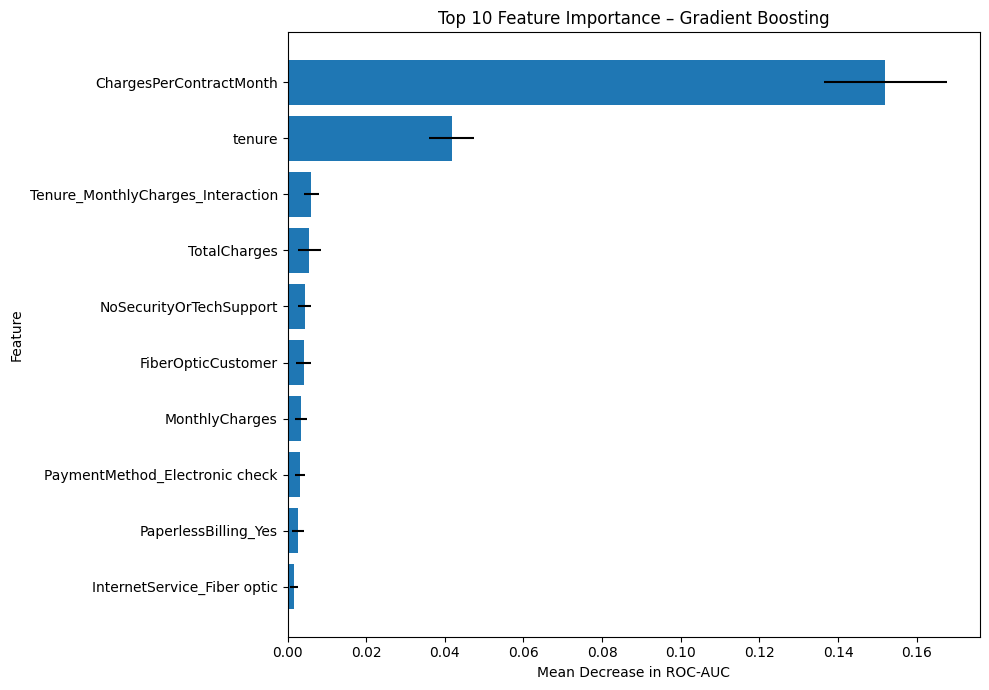

In [35]:
plot_data = (
    top_10_features
    .sort_values(
        by="Importance_Mean",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance_Mean"],
    xerr=plot_data[
        "Importance_Standard_Deviation"
    ]
)

plt.title(
    f"Top 10 Feature Importance – {best_model_name}"
)

plt.xlabel(
    "Mean Decrease in ROC-AUC"
)

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Top_10_Permutation_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

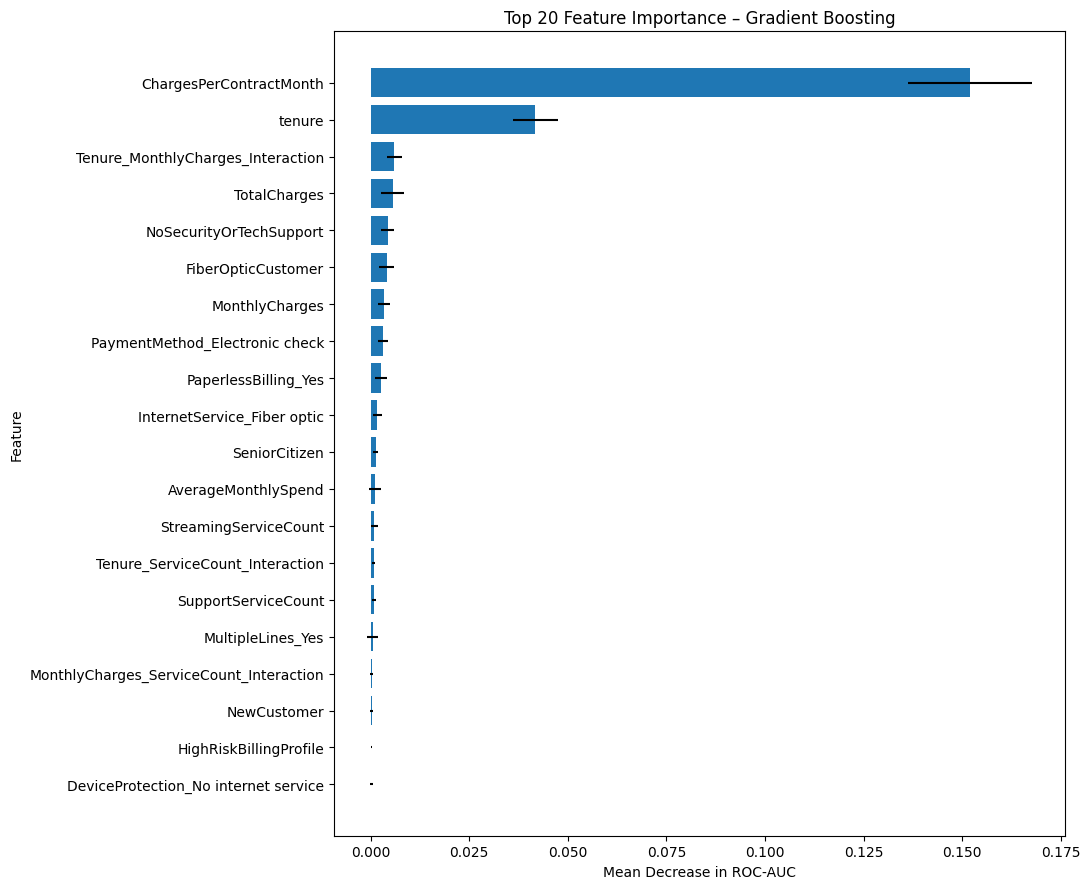

In [36]:
plot_data = (
    top_20_features
    .sort_values(
        by="Importance_Mean",
        ascending=True
    )
)

plt.figure(figsize=(11, 9))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance_Mean"],
    xerr=plot_data[
        "Importance_Standard_Deviation"
    ]
)

plt.title(
    f"Top 20 Feature Importance – {best_model_name}"
)

plt.xlabel(
    "Mean Decrease in ROC-AUC"
)

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Top_20_Permutation_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

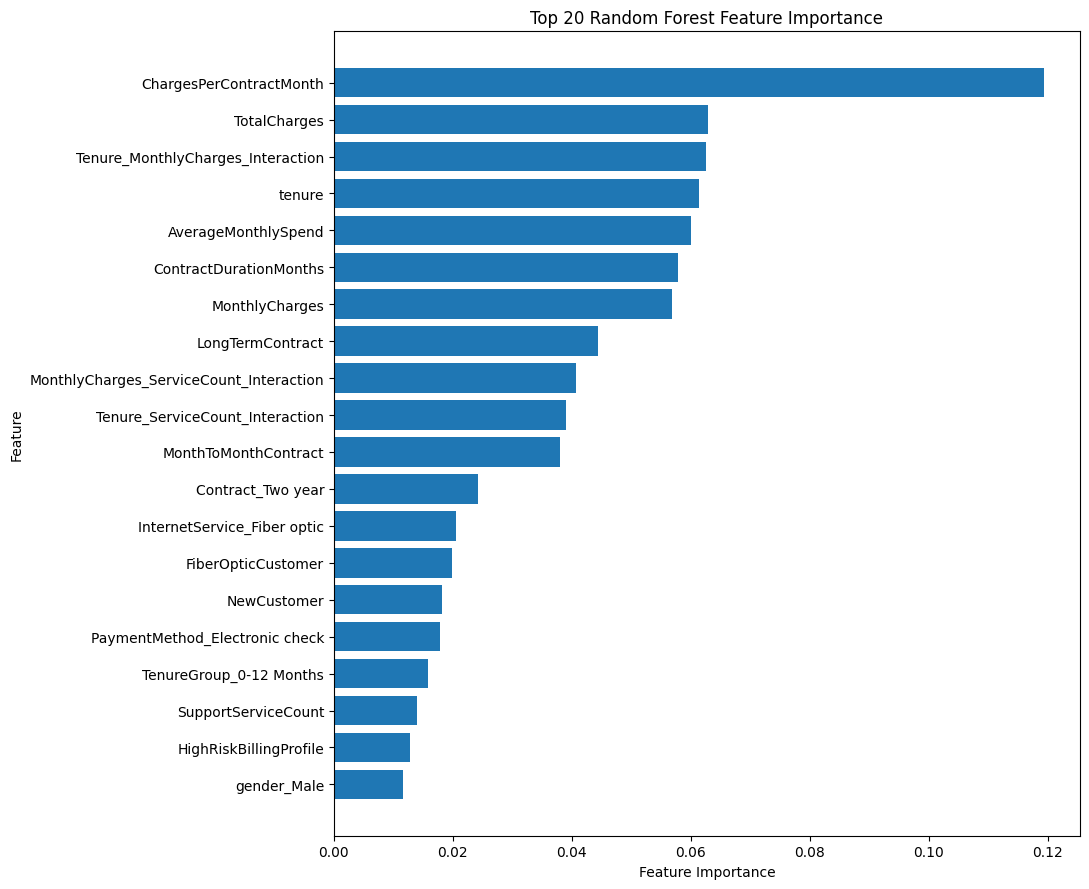

In [37]:
rf_top_20 = (
    random_forest_importance
    .head(20)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(11, 9))

plt.barh(
    rf_top_20["Feature"],
    rf_top_20["Importance"]
)

plt.title(
    "Top 20 Random Forest Feature Importance"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Random_Forest_Top_20_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

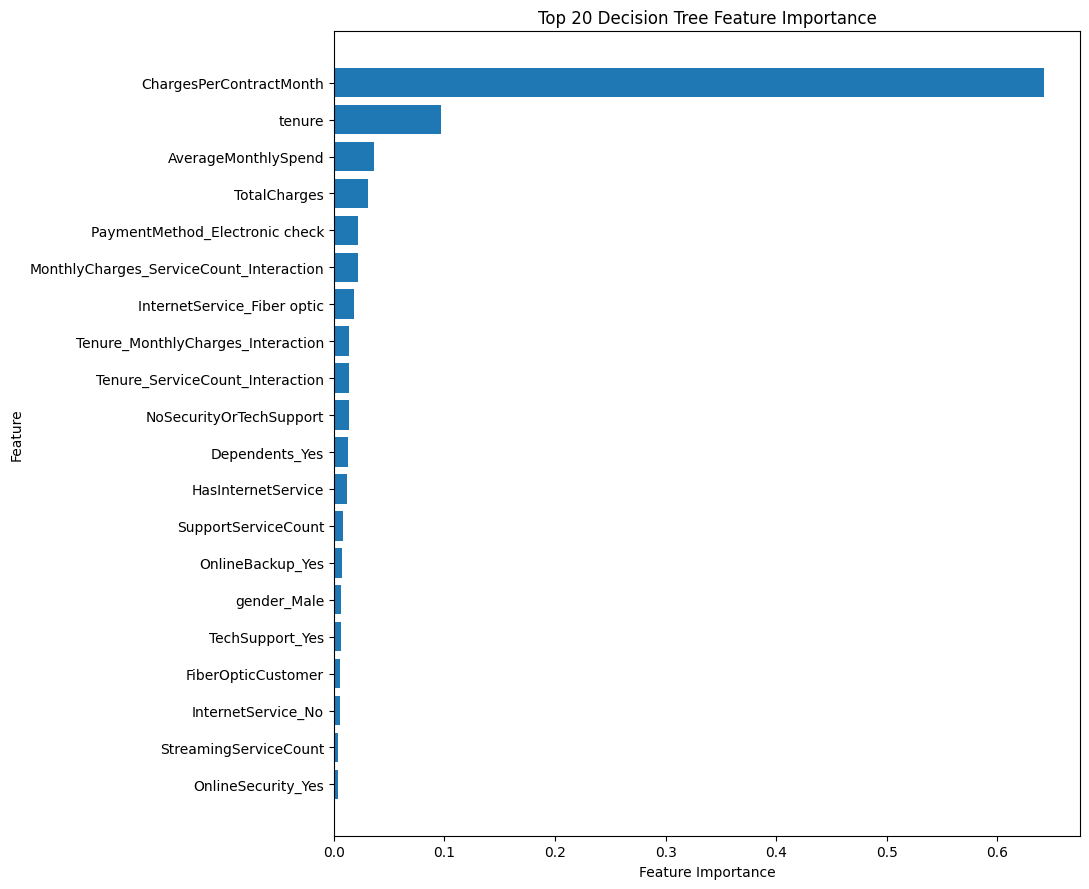

In [38]:
dt_top_20 = (
    decision_tree_importance
    .head(20)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(11, 9))

plt.barh(
    dt_top_20["Feature"],
    dt_top_20["Importance"]
)

plt.title(
    "Top 20 Decision Tree Feature Importance"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Decision_Tree_Top_20_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

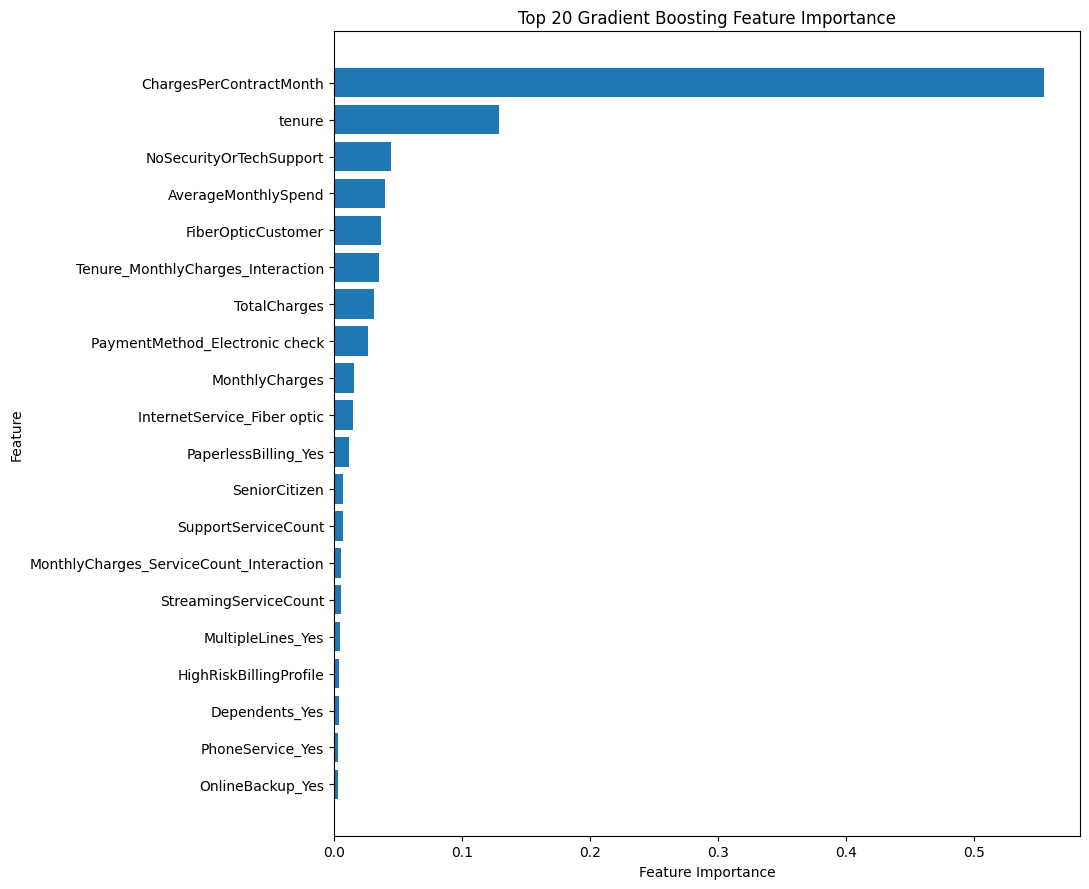

In [39]:
gb_top_20 = (
    gradient_boosting_importance
    .head(20)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(11, 9))

plt.barh(
    gb_top_20["Feature"],
    gb_top_20["Importance"]
)

plt.title(
    "Top 20 Gradient Boosting Feature Importance"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Gradient_Boosting_Top_20_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [40]:
positive_features = (
    logistic_importance[
        logistic_importance[
            "Coefficient"
        ] > 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(15)
    .sort_values(
        by="Coefficient",
        ascending=True
    )
)

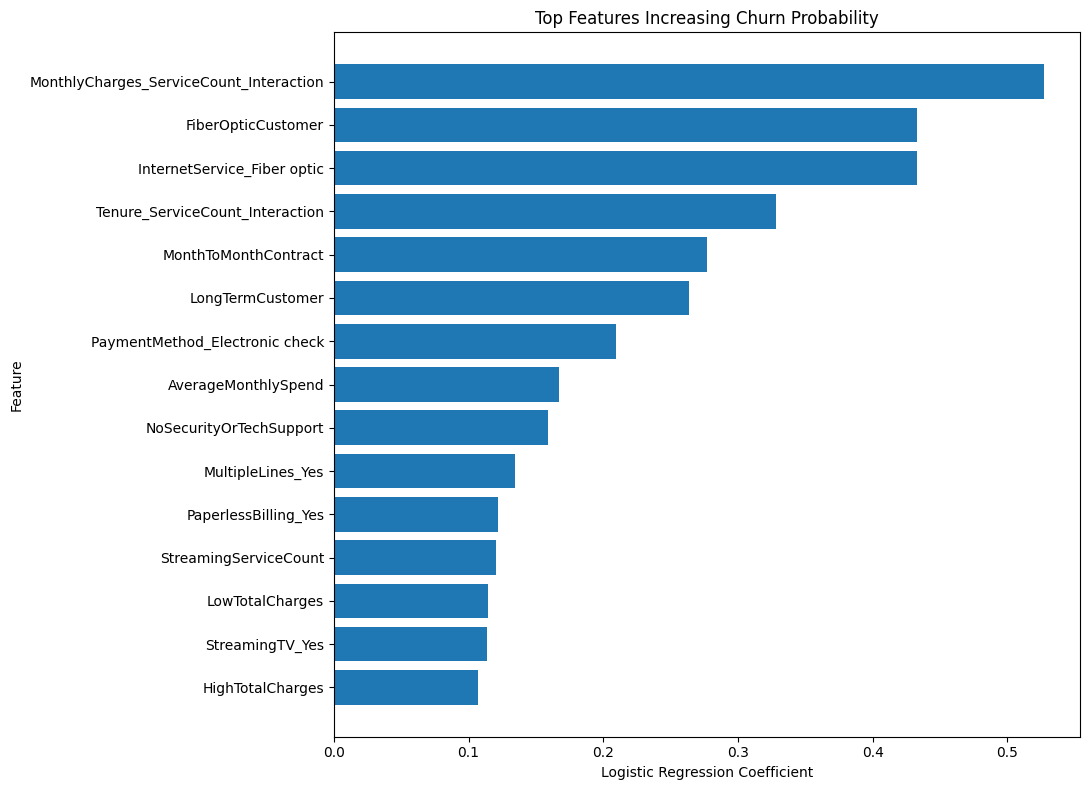

In [41]:
plt.figure(figsize=(11, 8))

plt.barh(
    positive_features["Feature"],
    positive_features["Coefficient"]
)

plt.title(
    "Top Features Increasing Churn Probability"
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Top_Features_Increasing_Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [42]:
negative_features = (
    logistic_importance[
        logistic_importance[
            "Coefficient"
        ] < 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .head(15)
    .sort_values(
        by="Coefficient",
        ascending=False
    )
)

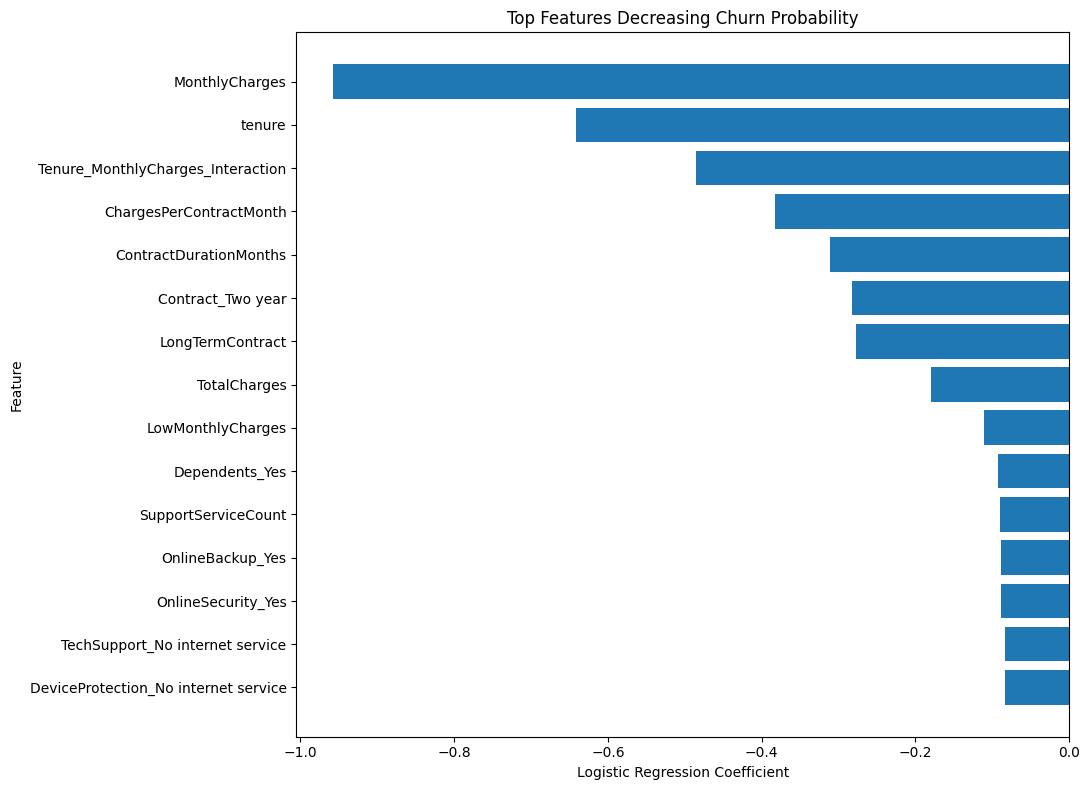

In [43]:
plt.figure(figsize=(11, 8))

plt.barh(
    negative_features["Feature"],
    negative_features["Coefficient"]
)

plt.title(
    "Top Features Decreasing Churn Probability"
)

plt.xlabel(
    "Logistic Regression Coefficient"
)

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Top_Features_Decreasing_Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [44]:
combined_importance = pd.concat(
    [
        decision_tree_importance[
            [
                "Feature",
                "Importance",
                "Model"
            ]
        ],

        random_forest_importance[
            [
                "Feature",
                "Importance",
                "Model"
            ]
        ],

        gradient_boosting_importance[
            [
                "Feature",
                "Importance",
                "Model"
            ]
        ]
    ],
    ignore_index=True
)

display(combined_importance.head())

,Feature,Importance,Model
0,ChargesPerContractMonth,0.642503,Decision Tree
1,tenure,0.096707,Decision Tree
2,AverageMonthlySpend,0.035855,Decision Tree
3,TotalCharges,0.030813,Decision Tree
4,PaymentMethod_Electronic check,0.021903,Decision Tree


In [45]:
combined_importance.to_csv(
    f"{importance_path}/"
    "Combined_Tree_Model_Feature_Importance.csv",
    index=False
)

In [46]:
average_tree_importance = (
    combined_importance
    .groupby(
        "Feature",
        as_index=False
    )["Importance"]
    .mean()
    .rename(
        columns={
            "Importance":
                "Average_Importance"
        }
    )
    .sort_values(
        by="Average_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

average_tree_importance["Rank"] = (
    average_tree_importance.index + 1
)

average_tree_importance = (
    average_tree_importance[
        [
            "Rank",
            "Feature",
            "Average_Importance"
        ]
    ]
)

display(
    average_tree_importance.head(20)
)

,Rank,Feature,Average_Importance
0,1,ChargesPerContractMonth,0.438940
1,2,tenure,0.095631
2,3,AverageMonthlySpend,0.045156
3,4,TotalCharges,0.041596
4,5,Tenure_MonthlyCharges_Interaction,0.037195
5,6,MonthlyCharges,0.025200
6,7,NoSecurityOrTechSupport,0.022822
7,8,MonthlyCharges_ServiceCount_Interaction,0.022695
8,9,PaymentMethod_Electronic check,0.021999
9,10,FiberOpticCustomer,0.020669


In [47]:
average_tree_importance.to_csv(
    f"{importance_path}/"
    "Average_Tree_Model_Feature_Importance.csv",
    index=False
)

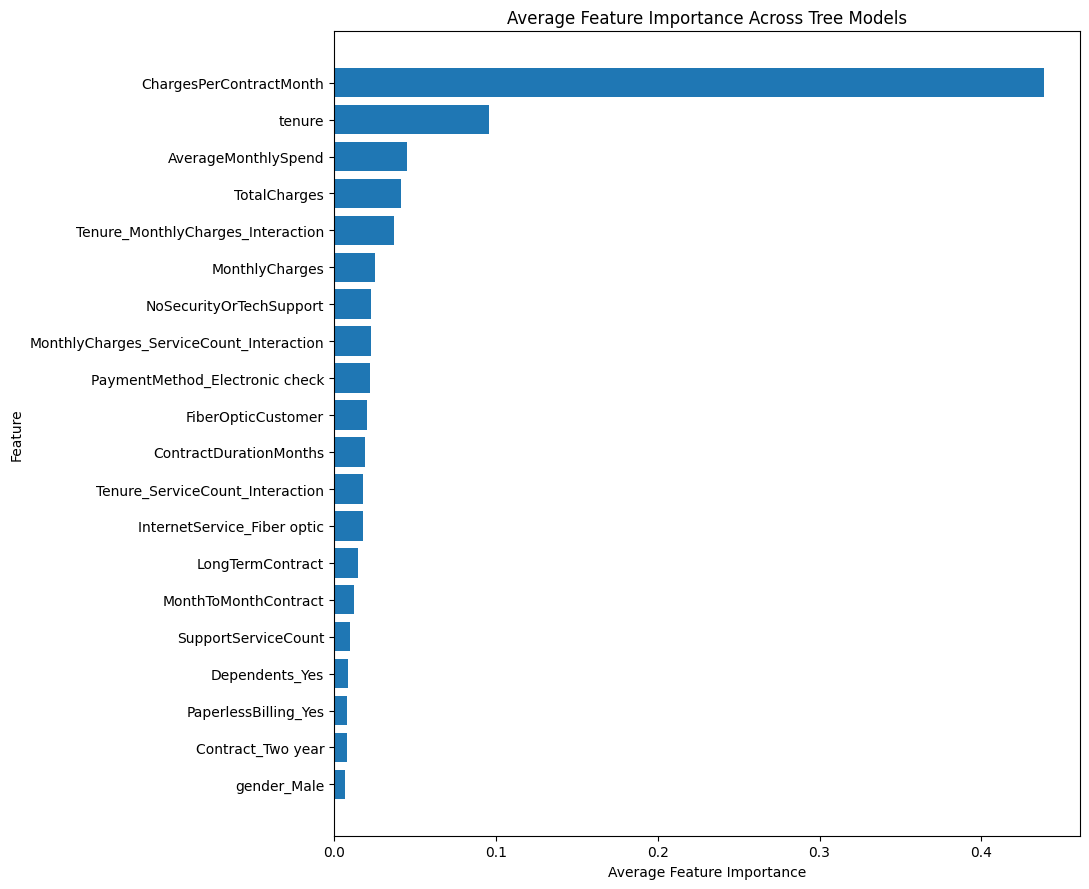

In [48]:
average_top_20 = (
    average_tree_importance
    .head(20)
    .sort_values(
        by="Average_Importance",
        ascending=True
    )
)

plt.figure(figsize=(11, 9))

plt.barh(
    average_top_20["Feature"],
    average_top_20[
        "Average_Importance"
    ]
)

plt.title(
    "Average Feature Importance Across Tree Models"
)

plt.xlabel("Average Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    f"{image_path}/"
    "Average_Tree_Model_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [49]:
summary_rows = []

In [50]:
for _, row in top_10_features.iterrows():

    summary_rows.append({
        "Rank": row["Rank"],
        "Feature": row["Feature"],
        "Permutation_Importance":
            row["Importance_Mean"],
        "Interpretation": (
            "Higher values indicate a stronger "
            "contribution to churn prediction."
        )
    })

In [51]:
feature_importance_summary = pd.DataFrame(
    summary_rows
)

display(feature_importance_summary)

,Rank,Feature,Permutation_Importance,Interpretation
0,1,ChargesPerContractMonth,0.152008,Higher values indicate a stronger contribution...
1,2,tenure,0.041747,Higher values indicate a stronger contribution...
2,3,Tenure_MonthlyCharges_Interaction,0.006069,Higher values indicate a stronger contribution...
3,4,TotalCharges,0.005570,Higher values indicate a stronger contribution...
4,5,NoSecurityOrTechSupport,0.004350,Higher values indicate a stronger contribution...
5,6,FiberOpticCustomer,0.004112,Higher values indicate a stronger contribution...
6,7,MonthlyCharges,0.003461,Higher values indicate a stronger contribution...
7,8,PaymentMethod_Electronic check,0.003204,Higher values indicate a stronger contribution...
8,9,PaperlessBilling_Yes,0.002699,Higher values indicate a stronger contribution...
9,10,InternetService_Fiber optic,0.001726,Higher values indicate a stronger contribution...


In [52]:
feature_importance_summary.to_csv(
    f"{importance_path}/"
    "Feature_Importance_Summary.csv",
    index=False
)

In [53]:
print("Feature importance outputs:\n")

for item in sorted(
    os.listdir(importance_path)
):
    print(item)

Feature importance outputs:

Average_Tree_Model_Feature_Importance.csv
Best_Model_Native_Feature_Importance.csv
Best_Model_Permutation_Importance.csv
Combined_Tree_Model_Feature_Importance.csv
Decision_Tree_Feature_Importance.csv
Feature_Importance_Summary.csv
Gradient_Boosting_Feature_Importance.csv
Images
Logistic_Regression_Coefficient_Importance.csv
Random_Forest_Feature_Importance.csv
Top_10_Features.csv
Top_20_Features.csv


In [54]:
zip_base = (
    "/content/Feature_Importance_Outputs"
)

shutil.make_archive(
    zip_base,
    "zip",
    importance_path
)

print("ZIP file created successfully:")
print(f"{zip_base}.zip")

ZIP file created successfully:
/content/Feature_Importance_Outputs.zip


In [55]:
from google.colab import files

files.download(
    "/content/Feature_Importance_Outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>